Detecting spam automatically is very crucial as it helps prevent unnessecary clutter in user's inbox.
For this project I start by importing necessarly libralies including Tensorflow, wordcloud, nltk among others.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings 
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HomePC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading the data email.csv

In [2]:
data = pd.read_csv('spam_ham_dataset.csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [3]:
data.shape

(5171, 4)

We can now visualize label distribution in order to understand the class distribution

<Axes: xlabel='label', ylabel='count'>

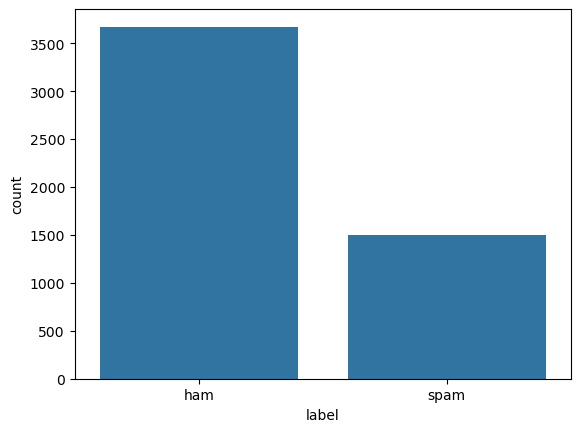

In [4]:
sns.countplot(x='label', data=data)

This clearly shows imbalance in the dataset we are using as the number of Ham is more than that of Spam.We have to address the imbalance by downsampling Ham as the majority class to match the minority class (Spam).

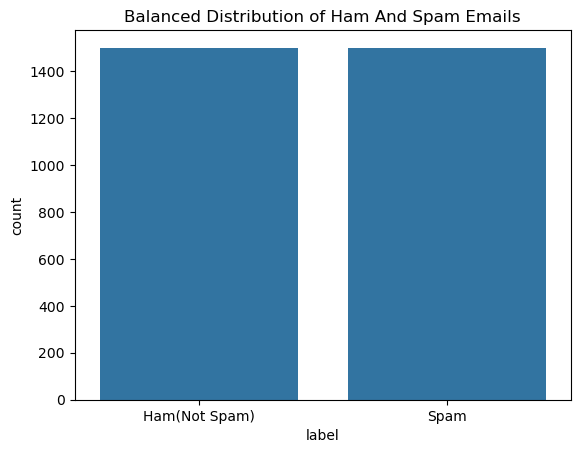

In [5]:
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

#Downsampling Ham emails to match the number of spam emails
ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state = 42)


#Combine balanced data
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

#Visualize the balanced dataset
sns.countplot(x = 'label', data = balanced_data)
plt.title("Balanced Distribution of Ham And Spam Emails")
plt.xticks(ticks = [0,1], labels = ['Ham(Not Spam)', 'Spam'])
plt.show()


Cleaning the text

In [6]:
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '')
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [7]:
punctuations_list = string.punctuation
def remove_punctuations(text):
    temp = str.maketrans('', '', punctuations_list)
    return text.translate(temp)


balanced_data['text'] = balanced_data['text'].apply(lambda x: remove_punctuations(x))
balanced_data.head()


,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


In [8]:
def remove_stopwords(text):
    stop_words = stopwords.words('english')

    imp_words = []

    # Storing the important words
    for word in str(text).split():
        word = word.lower()

        if word not in stop_words:
            imp_words.append(word)

    output = " ".join(imp_words)

    return output


balanced_data['text'] = balanced_data['text'].apply(lambda text: remove_stopwords(text))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


Using word cloud to visualize insights on the most frequent words present in the corpus of the data

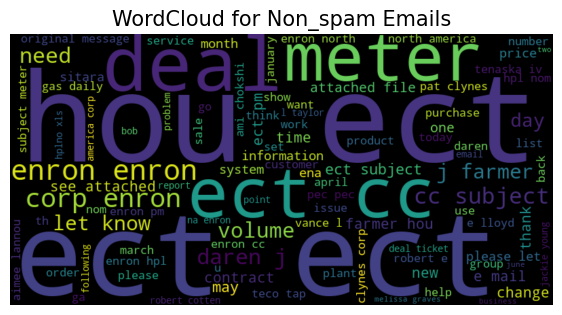

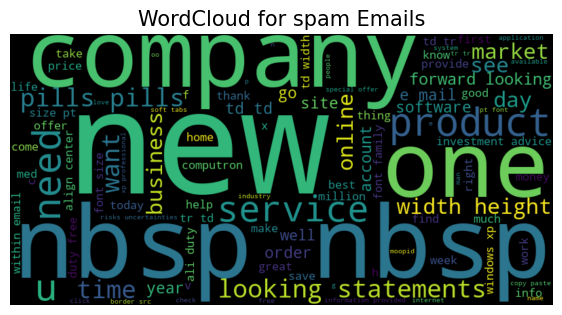

In [9]:
def plot_word_cloud(data, typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color = 'black', 
                   max_words = 100, 
                   width = 800, 
                   height =400).generate(email_corpus)
    plt.figure(figsize=(7,7))
    plt.imshow(wc, interpolation = 'bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ = 'Non_spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ = 'spam')

Removing duplicates to ensure dataset is clean.

In [10]:
balanced_data = balanced_data.drop_duplicates(subset='text')

We have to convert the text data into numerical vectors using Tokenization and padding.

In [11]:
train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data['text'], balanced_data['label'], test_size=0.2, random_state=42
)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100  # Maximum sequence length
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)

Now we build a deep learning model using sequential architecture. 

In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(max_len,)),
    tf.keras.layers.Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=32
    ),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 32)        │     1,260,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,263,841 (4.82 MB)

 Trainable params: 1,263,841 (4.82 MB)

 Non-trainable params: 0 (0.00 B)

We now train the model using Earlystopping and ReduleLROnplateau callbacks.

In [13]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequences, train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)


Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.5793 - loss: 0.6867 - val_accuracy: 0.6838 - val_loss: 0.5886 - learning_rate: 0.0010
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9295 - loss: 0.2540 - val_accuracy: 0.9227 - val_loss: 0.2499 - learning_rate: 0.0010
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9549 - loss: 0.1617 - val_accuracy: 0.9450 - val_loss: 0.2153 - learning_rate: 0.0010
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9661 - loss: 0.1390 - val_accuracy: 0.9450 - val_loss: 0.2137 - learning_rate: 0.0010
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9725 - loss: 0.1195 - val_accuracy: 0.9467 - val_loss: 0.2117 - learning_rate: 0.0010
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9600 - loss: 0.1720 - val_accuracy: 0.9467 - val_loss: 0.2187 - learning_rate: 0.0010
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9699 - loss: 0.1252 - val_acc

We now evaluate the model on the test data to measure its perfomance.

In [14]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9467 - loss: 0.2117
Test Loss: 0.21171893179416656
Test Accuracy: 0.9467353820800781


Testing for data leackage to confirm if same emails appear in train and test. This also helps to confirm if data was properly shuffled before split.

In [15]:
print(len(set(train_X).intersection(set(test_X))))

0


In [ ]:
Checking confusion matrix.

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

pred = (model.predict(test_sequences) > 0.5).astype(int)

print(confusion_matrix(test_Y, pred))
print(classification_report(test_Y, pred))

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
[[288  18]
 [ 13 263]]
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       306
           1       0.94      0.95      0.94       276

    accuracy                           0.95       582
   macro avg       0.95      0.95      0.95       582
weighted avg       0.95      0.95      0.95       582



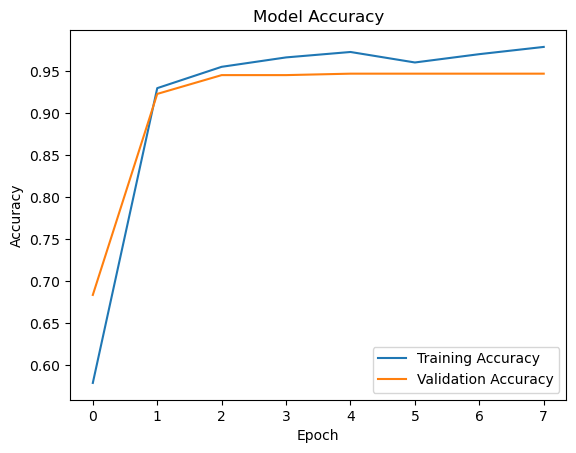

In [17]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Model Performance Summary

## Final Evaluation Results

The trained LSTM-based spam classifier achieved the following performance on the test dataset:

* **Test Accuracy:** 94.7%
* **Test Loss:** 0.21

These results indicate strong generalization and reliable performance on unseen data.

---

## Confusion Matrix

```text
[[288  18]
 [ 13 263]]
```

### Interpretation:

* **288** → Correctly classified ham (True Negatives)
* **263** → Correctly classified spam (True Positives)
* **18** → Ham incorrectly classified as spam (False Positives)
* **13** → Spam incorrectly classified as ham (False Negatives)

---

## Classification Metrics

| Class    | Precision | Recall | F1-Score |
| -------- | --------- | ------ | -------- |
| Ham (0)  | 0.96      | 0.94   | 0.95     |
| Spam (1) | 0.94      | 0.95   | 0.94     |

### Key Insights:

* The model maintains **high precision and recall across both classes**
* Spam detection recall (0.95) indicates most spam messages are correctly identified
* Balanced F1-scores show no bias toward either class

---

## Performance Interpretation

* The model correctly classifies approximately **95 out of 100 messages**
* Misclassification rate is low (~5%)
* Errors are evenly distributed between false positives and false negatives
* The classifier is both **accurate and well-balanced**, making it reliable for practical use

---

## Validation Note

Initial results (~99% accuracy) were affected by data leakage due to duplicate samples across training and test sets.
After removing duplicates, the model achieved a more realistic and trustworthy accuracy of **94.7%**.

---

## Conclusion

The model demonstrates strong and consistent performance, with high accuracy, balanced classification metrics, and minimal error rates. It is suitable for real-world spam detection tasks with reliable prediction behavior.
